In [1]:
import argparse
from pathlib import Path
import yaml
import logging
import numpy as np
import rerun as rr
from typing import Tuple, Optional, Dict, Tuple
import os
os.chdir("/workspace")  # Set working directory to project root
from main_pseudo_union import get_out_dir
from src.data.dataset import load_dataset_scene, get_dataset_scene_names
from src.image.grounding_sam import generate_segmentation_masks
from src.image.segmentation_reprojection import reproject_lidar_to_segmentation
from src.pointcloud.cluster_denoising import denoise_object_clusters
from src.pointcloud.remove_ground import remove_ground
from src.image.appearance_embedding import appearance_embed_mask_based
from src.tracking.appearance_tracking import estimate_velocity_by_appearance_tracking
from src.image.object_merge import merge_multicamera_objects
from src.labeling.prior_info import get_common_object_infos_sam
from src.structures import Scene, CommonObjectInfo
from src.data import EXP_PSEUDO_OUT_PATH
from src.pointcloud.bbox_heuristic import estimate_yaw_from_tracking_and_shape, inflate_bboxes_to_common_size
logging.root.setLevel(logging.INFO)
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
np.set_printoptions(suppress=True)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [ ]:
config_file = Path("configs/vlm/baseline-mini-tracker.yaml")
with open(config_file, 'r') as f:
    config = yaml.safe_load(f)
assert config['type'] == 'vlm', f"Config file {config_file} is not a valid config file for this script"
config['exp_name'] = config_file.stem
scenes = ["scene-0061"]
scene_names_all: list[str] = get_dataset_scene_names(config['data'])
scene_names = scene_names_all if scenes is None else scenes
assert all([scene_name in scene_names_all for scene_name in scene_names]), \
    f"Some scenes {scenes} are not in the dataset"
obj_info: Dict[str, CommonObjectInfo] = get_common_object_infos_sam(config['grounding_sam']['class_names'])

scene_name = scenes[0]
idx = 0
logger.info(f"#####Running labeling (and visualization) for scene {scene_name}, {idx+1}/{len(scene_names)}#####")
logger.info("Loading cached steps")
base_scene: Scene = load_dataset_scene(config['data'], scene_name)
scene_wo_ground: Scene = remove_ground(base_scene,
                                    config['remove_ground'],
                                    get_out_dir(config, '01_remove_ground'))

logger.info("Generating segmentation masks")
scene_w_segmentation: Scene = generate_segmentation_masks(scene_wo_ground,
                                                        config['grounding_sam'],
                                                        get_out_dir(config, '02_grounding_sam'))

logger.info("Reprojecting lidar to segmentation")
scene_w_segclusters = reproject_lidar_to_segmentation(scene_w_segmentation,
                                                    config['reprojection'],
                                                    get_out_dir(config, '03_reprojection'))

logger.info("Denoising object clusters")
scene_w_segclusters_denoised = denoise_object_clusters(scene_w_segclusters,
                                                    obj_info,
                                                    config['denoising'],
                                                    get_out_dir(config, '04_denoising'))

logger.info("Appearance embedding based on masks")
scene_w_segclusters_embed = appearance_embed_mask_based(scene_w_segclusters_denoised,
                                                        config['appearance_embedding'],
                                                        get_out_dir(config, '05_appearance_embedding_mask'))

logger.info("Merging multicamera objects")
scene_w_segclusters_merged = merge_multicamera_objects(scene_w_segclusters_embed,
                                                    obj_info,
                                                    config['multicam_object_merge'],
                                                    get_out_dir(config, '06_multicam_object_merge'))
logger.info("Estimating velocity and tracklets")
scene_w_segclusters_velo = estimate_velocity_by_appearance_tracking(scene_w_segclusters_merged,
                                                        obj_info,
                                                        config['velocity_by_app_tracking'],
                                                        get_out_dir(config, '075_velocity_by_tracking'))
print("Done velocity estimation by appearance tracking.")

logger.info("Estimating yaw from tracking and shape")
scene_w_segclusters_yaw = estimate_yaw_from_tracking_and_shape(scene_w_segclusters_velo,
                                                                obj_info, config['yaw_heuristic'])

#### Convert to Method and use configs
logger.info("Inflating bboxes to common size")
scene_w_segclusters_inflated = inflate_bboxes_to_common_size(scene_w_segclusters_yaw, obj_info, config['bbox_inflation'])

INFO:__main__:#####Running labeling (and visualization) for scene scene-0061, 1/1#####
INFO:__main__:Loading cached steps
100%|██████████| 382/382 [00:00<00:00, 1663.93it/s]
INFO:__main__:Generating segmentation masks
100%|██████████| 382/382 [00:01<00:00, 194.44it/s]
INFO:__main__:Reprojecting lidar to segmentation
100%|██████████| 39/39 [00:00<00:00, 44.79it/s]
INFO:__main__:Denoising object clusters
100%|██████████| 39/39 [00:00<00:00, 2149.71it/s]
INFO:__main__:Appearance embedding based on masks
100%|██████████| 39/39 [00:00<00:00, 883.73it/s]
INFO:__main__:Merging multicamera objects
100%|██████████| 39/39 [00:00<00:00, 165.00it/s]
INFO:__main__:Estimating velocity and tracklets
INFO:__main__:Estimating yaw from tracking and shape


Done velocity estimation by appearance tracking.


100%|██████████| 39/39 [00:00<00:00, 1495.13it/s]


INFO:__main__:Inflating bboxes to common size
100%|██████████| 39/39 [00:00<00:00, 2287.42it/s]


In [12]:
from src.visualizations.rerun import get_rerun_blueprint
from src.visualizations.modules import visualize_base_scene, visualize_camera_segmentations, visualize_lidar
from src.visualizations.modules import visualize_object_pointclouds, visualize_object_boxes
logger.info("Setting up rerun")
rerun_blueprint = get_rerun_blueprint(base_scene.camera_to_image.keys())
rr.init("tracking false",spawn=False)
rr.send_blueprint(rerun_blueprint)
rr.connect_grpc(default_blueprint=rerun_blueprint,)

# logger.info("Visualizing scene")
visualize_base_scene(base_scene, config.get('visualization', {}))

logger.info("Visualizing scene after scene flow")
visualize_object_pointclouds(scene_w_segclusters_inflated, "085_tracking", "index")
visualize_object_boxes(scene_w_segclusters_inflated, "085_tracking", "085_tracking_bbox", lambda obj: obj.track_id)

INFO:__main__:Setting up rerun
INFO:__main__:Visualizing scene after scene flow


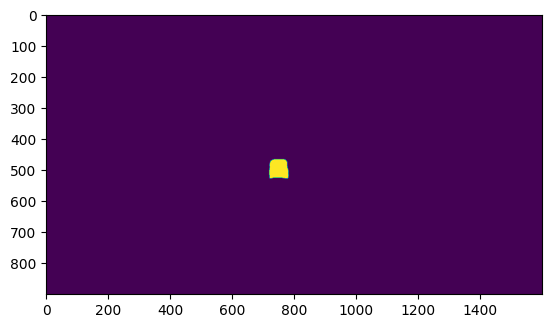

In [5]:
scene_w_segclusters_yaw.frames[0].objects[3].cam_masks
import matplotlib.pyplot as plt

cam_masks = scene_w_segclusters_yaw.frames[0].objects[3].cam_masks[0]

plt.figure()
plt.imshow(cam_masks)
plt.show()

In [6]:
rr.__version__

'0.25.1'